# Moving-Average Envelopes — a quantitative teardown
### Daily OHLC · SMA(20) ±5% · long/flat timing · one execution lag · net excess-vs-excess Sharpe · HAC *t* · block-permutation placebo

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats Bollinger%3F: Busted](https://img.shields.io/badge/Beats_Bollinger%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We turn the percent envelope into a daily long/flat book, race its **net, excess-of-cash** Sharpe against buy-and-hold and the two simpler benchmarks (Bollinger, SMA(200)), and ask a block-permutation placebo whether the band times anything beyond exposure.

> **Not investment advice.** Real data: Yahoo daily bars (total-return adjusted), five index tapes, as-of **2026-06-23**; the offline core and tests run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#2c6fbb"

from ma_envelopes import data, strategy as st

ASOF = "2026-06-23"
TICKERS = ["SPY", "QQQ", "DIA", "IWM", "EFA"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def close(t):
    return data.fetch_daily(t, fetch=False, cache_dir=CACHE).loc[:ASOF]["close"]

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front (real tape)

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | SPY envelope net Sharpe **+0.278**, HAC *t* = **+1.97** (below 2); block-permutation placebo *p* = **0.232**. |
| **Tradability** | `MIRAGE` | In market **6.6%** of the time; loses to buy-and-hold (**+0.644**) and SMA(200) (**+0.727**). |
| **Beats Bollinger?** | `BUSTED` | Bollinger **+0.444** > envelope **+0.278** on the identical rule; Bollinger wins 4/5 tapes. |

> In plain words: a fixed-percent band on a diversified index is diluted beta. It earns a positive Sharpe only by being long when the market happens to drift up — and a volatility-scaled band does the same job better.

## 1 · The claim, steelmanned

The envelope is the SMA flanked by fixed-percent lines:

$$\text{mid}_t = \text{SMA}_n(C),\quad \text{upper}_t = \text{mid}_t(1+k),\quad \text{lower}_t = \text{mid}_t(1-k)$$

versus Bollinger's *volatility-scaled* half-width $\text{upper}_t = \text{mid}_t + m\,\sigma_{n,t}$. The long/flat rule: position $w_t = 1$ once $C_t < \text{lower}_t$, held until $C_t \ge \text{mid}_t$, else $0$. With one execution lag the book earns $w_{t-1} r_t$. The hypotheses:

- **H₁ (signal).** The net, excess-of-cash Sharpe of $\{w_{t-1} r_t\}$ is positive at HAC *t* ≥ 2.
- **H₂ (information, not exposure).** That Sharpe sits in the right tail of a block-permutation null that **preserves the marginal long-fraction** but scrambles the timing.
- **H₃ (better than Bollinger).** Its net Sharpe exceeds the Bollinger band's on the same rule/instrument/window.
- **H₄ (worth trading).** It beats buy-and-hold net of costs.

We reject **H₁** (*t* < 2), **H₂** (*p* = 0.23), **H₃** (Bollinger wins) and **H₄** (buy-and-hold wins).

## 2 · So what? — what rides on each answer

Envelopes are taught as a *simpler, more stable* alternative to Bollinger Bands. If H₁–H₄ held, the fixed band would be a free upgrade — lower turnover, no volatility estimation, and a better Sharpe. The finding that it is the *weakest* of envelope / Bollinger / SMA(200) / buy-and-hold matters: it means the 'stability' advocates prize is exactly what makes it fire too rarely and too late, and the rule's apparent edge is just under-exposed beta.

## 3 · How we'd know — the protocol

- **Indicator.** SMA(20), envelope width $k = 5\%$ (Bollinger $m = 2\sigma$, SMA filter $n = 200$ as benchmarks).
- **Rule.** Long while $C < \text{lower}$, exit at the mid (the recipe's own exit), flat otherwise. Breakout variant ($C > \text{upper}$) tested separately.
- **Execution.** One lag — position known at close $t$ earns return $t{+}1$ (`book_returns` applies a single `shift(1)`).
- **Costs.** One-way bps × |Δposition| × NAV; excess-of-cash on the exposed notional; shorts (L/S variant) pay borrow.
- **Race.** Net Sharpe, **excess-of-cash vs excess-of-cash**, against buy-and-hold, Bollinger and SMA(200).
- **Inference.** Newey–West HAC *t* on daily net returns; a **circular block-permutation placebo** (21-day blocks of the *position*, exposure preserved).
- **Positive control.** Synthetic OU tape (`data.synthetic_panel`, `edge` = reversion speed) confirming the engine banks a *planted* envelope edge.

Five tapes (SPY, QQQ, DIA, IWM, EFA) to inception; SPY headline n = 8,406, as-of 2026-06-23.

## 4 · The teardown

### 4a · The headline race — net Sharpe & HAC *t*, SPY

If the envelope earned its keep, it should clear *t* = 2 and beat the row below it.

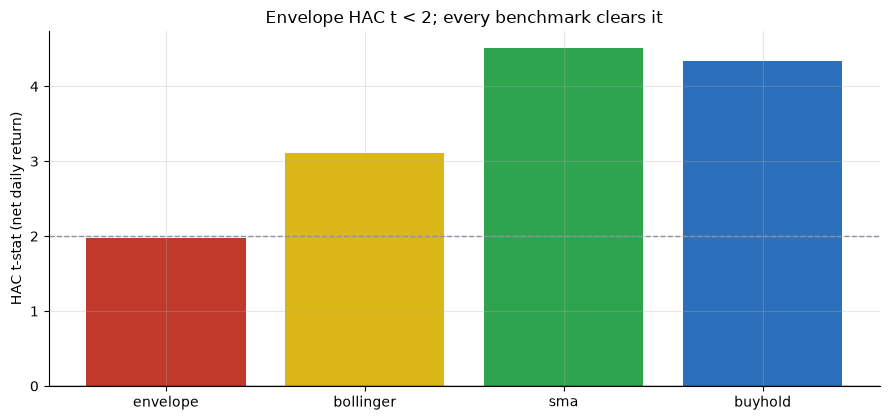

,strategy,sharpe,HAC_t,cagr%,maxdd%,inmkt%
0,envelope,0.278,1.974,2.453,-33.239,6.602
1,bollinger,0.444,3.107,4.862,-37.027,19.022
2,sma,0.727,4.510,8.324,-28.284,75.327
3,buyhold,0.644,4.333,10.781,-55.189,100.000


In [2]:
if HAVE_REAL:
    c = close('SPY')
    res = st.run_experiment(c, 20, 0.05, 'reversion', 1.0, n_perm=2000)
    rows = [(n, res[n]['sharpe'], res[n]['tstat'], res[n]['cagr']*100,
             res[n]['maxdd']*100, res[n]['exposure']*100)
            for n in ['envelope','bollinger','sma','buyhold']]
    tbl = pd.DataFrame(rows, columns=['strategy','sharpe','HAC_t','cagr%','maxdd%','inmkt%'])
    perm = res['perm']
else:
    tbl = pd.DataFrame({
        'strategy': ['envelope','bollinger','sma','buyhold'],
        'sharpe': [0.278,0.444,0.727,0.644],
        'HAC_t': [1.97,3.11,4.51,4.33],
        'cagr%': [2.45,4.86,8.32,10.78],
        'maxdd%': [-33.2,-37.0,-28.3,-55.2],
        'inmkt%': [6.6,19.0,75.3,100.0]})
    perm = dict(stat_real=0.278, perm_mean=0.168, p_value=0.232)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [RED, AMBER, GREEN, BLUE]
ax.bar(tbl['strategy'], tbl['HAC_t'], color=col)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat (net daily return)')
ax.set_title('Envelope HAC t < 2; every benchmark clears it')
plt.tight_layout(); plt.show()
tbl.round(3)

> In plain words: the envelope's *t* = **1.97** misses the bar, while buy-and-hold (*t* = 4.33) and even a bare SMA(200) (*t* = 4.51) clear it comfortably. The envelope is the only one of the four that *can't* certify a positive mean return.

### 4b · The decisive arbiter — block-permutation placebo

Scramble the position in 21-day blocks (exposure preserved, timing destroyed) and ask where the real Sharpe falls.

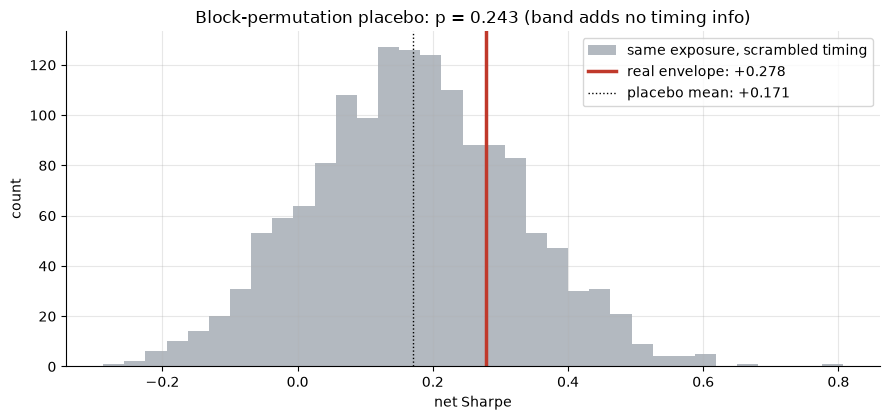

real +0.278  vs  scrambled mean +0.171  ->  p = 0.243


In [3]:
if HAVE_REAL:
    pos = st.envelope_position(c, 20, 0.05, 'reversion')
    rng = np.random.default_rng(436); npos = pos.to_numpy(); N=len(npos); blk=21
    samp = []
    for _ in range(1500):
        starts = rng.integers(0,N,size=int(np.ceil(N/blk)))
        sc = np.concatenate([np.take(npos,range(s,s+blk),mode='wrap') for s in starts])[:N]
        samp.append(st.summarize(st.book_returns(c, pd.Series(sc,index=pos.index),1.0),'net')['sharpe'])
    real, pv = perm['stat_real'], float((np.array(samp) >= perm['stat_real']).mean())
else:
    real, pv = 0.278, 0.232
    samp = list(np.random.default_rng(0).normal(0.168, 0.08, 1500))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(samp, bins=35, color=GREY, alpha=.65, label='same exposure, scrambled timing')
ax.axvline(real, c=RED, lw=2.5, label=f'real envelope: {real:+.3f}')
ax.axvline(np.mean(samp), c='k', lw=1, ls=':', label=f'placebo mean: {np.mean(samp):+.3f}')
ax.set_xlabel('net Sharpe'); ax.set_ylabel('count')
ax.set_title(f'Block-permutation placebo: p = {pv:.3f} (band adds no timing info)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'real {real:+.3f}  vs  scrambled mean {np.mean(samp):+.3f}  ->  p = {pv:.3f}')

> In plain words: *p* = **0.23**. A randomly mis-timed path with the same long-fraction matches the real envelope about a quarter of the time. The edge is the exposure, not the band — the sharpest possible refutation of H₂.

### 4c · Panel — the same null across five index tapes

Envelope vs Bollinger vs buy-and-hold (net 1 bp).

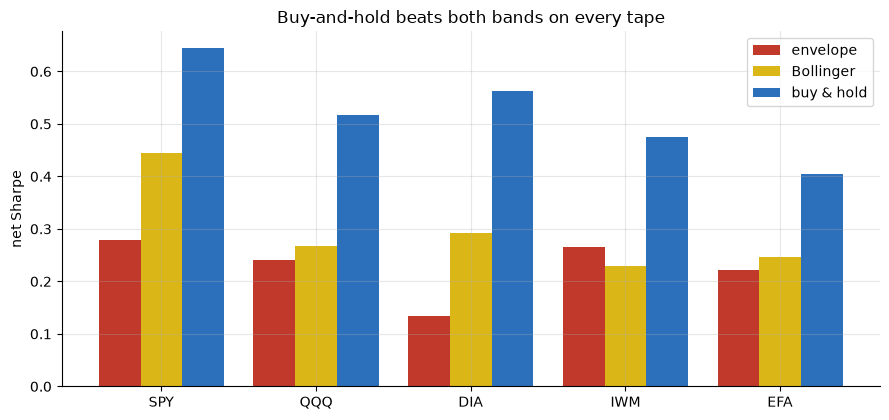

,env_S,env_t,boll_S,boll_t,bh_S
SPY,0.278,1.974,0.444,3.107,0.644
QQQ,0.241,1.584,0.267,1.759,0.517
DIA,0.133,0.973,0.293,1.942,0.563
IWM,0.265,1.532,0.230,1.315,0.474
EFA,0.222,1.485,0.246,1.546,0.404


In [4]:
panel = {}
if HAVE_REAL:
    for t in TICKERS:
        cc = close(t)
        e = st.summarize(st.book_returns(cc, st.envelope_position(cc,20,0.05,'reversion'),1.0),'net')
        bo = st.summarize(st.book_returns(cc, st.bollinger_position(cc,20,2.0,'reversion'),1.0),'net')
        bh = st.summarize(pd.DataFrame({'net':st.buy_and_hold_excess(cc),'pos':pd.Series(1.0,index=cc.index)}),'net')
        panel[t] = (e['sharpe'], e['tstat'], bo['sharpe'], bo['tstat'], bh['sharpe'])
else:
    panel = dict(SPY=(0.278, 1.97, 0.444, 3.11, 0.644), QQQ=(0.241, 1.58, 0.267, 1.76, 0.517), DIA=(0.133, 0.97, 0.293, 1.94, 0.563), IWM=(0.265, 1.53, 0.23, 1.31, 0.474), EFA=(0.222, 1.49, 0.246, 1.55, 0.404))
pt = pd.DataFrame(panel, index=['env_S','env_t','boll_S','boll_t','bh_S']).T
fig, ax = plt.subplots(figsize=(9.0, 4.3))
x = np.arange(len(pt)); w=.27
ax.bar(x-w, pt['env_S'], w, color=RED, label='envelope')
ax.bar(x,   pt['boll_S'], w, color=AMBER, label='Bollinger')
ax.bar(x+w, pt['bh_S'], w, color=BLUE, label='buy & hold')
ax.set_xticks(x); ax.set_xticklabels(pt.index)
ax.set_ylabel('net Sharpe'); ax.set_title('Buy-and-hold beats both bands on every tape')
ax.legend(); plt.tight_layout(); plt.show()
pt.round(3)

> In plain words: no tape clears *t* = 2 on the envelope; buy-and-hold beats every band everywhere; Bollinger beats the envelope on 4 of 5. The result is structural, not an SPY fluke.

### 4d · The width (*k*) sweep — tightening only adds exposure

A tighter band nudges *t* up — but only by buying more dips, i.e. adding beta.

In [5]:
if HAVE_REAL:
    ks = [0.02,0.03,0.05,0.08,0.10]
    rows=[]
    for kk in ks:
        s = st.summarize(st.book_returns(c, st.envelope_position(c,20,kk,'reversion'),1.0),'net')
        rows.append((kk, s['sharpe'], s['tstat'], s['exposure']*100))
    sw = pd.DataFrame(rows, columns=['k','sharpe','HAC_t','inmkt%'])
    display(sw.round(3))
    print('Smaller k -> more time in market -> higher t, but the placebo still flags it as exposure.')
else:
    print('k=0.02 t~2.74 (exp 21%);  k=0.05 t~1.97 (exp 7%);  k=0.10 t~2.07 (exp 1%) — t tracks exposure, not skill.')

,k,sharpe,HAC_t,inmkt%
0,0.02,0.386,2.736,20.997
1,0.03,0.382,2.698,14.823
2,0.05,0.278,1.974,6.602
3,0.08,0.211,1.637,2.296
4,0.10,0.237,2.070,1.344


Smaller k -> more time in market -> higher t, but the placebo still flags it as exposure.


## 5 · The verdict

- **Signal `NONE`** — SPY net Sharpe +0.278, HAC *t* +1.97 (< 2); placebo *p* = 0.232; no panel tape clears *t* = 2.
- **Tradability `MIRAGE`** — 6.6% time in market; net Sharpe below buy-and-hold (+0.644) and SMA(200) (+0.727); diluted beta.
- **Beats Bollinger? `BUSTED`** — Bollinger +0.444 > envelope +0.278; the fixed band is the weaker of the two.

## 6 · Could you trade it? — costs, and the breakout reading

Turnover is ~2.6 round-trips/yr, so costs barely register — but the gross already loses to holding. And flipping to the breakout reading is worse:

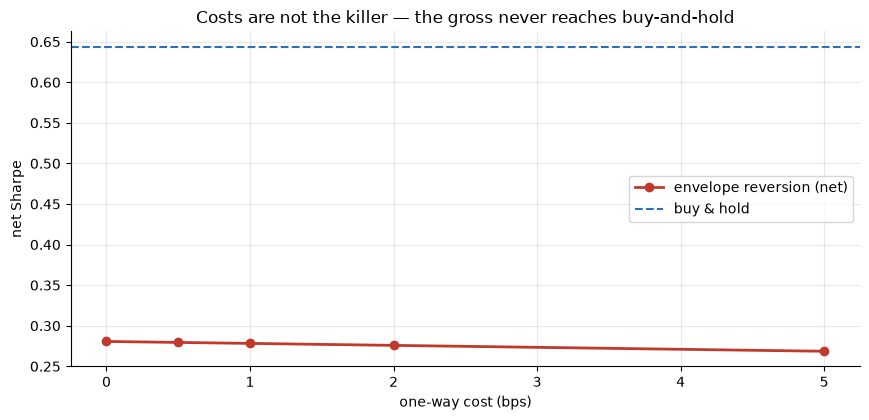

Breakout reading: envelope S=+0.116 (t=+0.78), Bollinger S=+0.156 (t=+0.98) — both worse.


In [6]:
if HAVE_REAL:
    costs=[0.0,0.5,1.0,2.0,5.0]
    net=[st.summarize(st.book_returns(c, st.envelope_position(c,20,0.05,'reversion'),x),'net')['sharpe'] for x in costs]
    eb = st.summarize(st.book_returns(c, st.envelope_position(c,20,0.05,'breakout'),1.0),'net')
    bb = st.summarize(st.book_returns(c, st.bollinger_position(c,20,2.0,'breakout'),1.0),'net')
    eb_s, eb_t, bb_s, bb_t = eb['sharpe'], eb['tstat'], bb['sharpe'], bb['tstat']
else:
    costs=[0.0,0.5,1.0,2.0,5.0]; net=[0.281,0.279,0.278,0.276,0.269]
    eb_s,eb_t,bb_s,bb_t = 0.116,0.78,0.156,0.98
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2, label='envelope reversion (net)')
ax.axhline(0.644, ls='--', c=BLUE, label='buy & hold')
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('Costs are not the killer — the gross never reaches buy-and-hold')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Breakout reading: envelope S={eb_s:+.3f} (t={eb_t:+.2f}), Bollinger S={bb_s:+.3f} (t={bb_t:+.2f}) — both worse.')

> In plain words: there is no cost at which the envelope catches buy-and-hold, and the trend-following 'buy the upper band' reading is worse still (*t* < 1). No version of the rule earns its keep.

## 7 · Going further — the positive control

Is the *engine* capable of finding an envelope edge, or does it always read null? Plant a mean-reverting deviation (an OU/AR(1) on the log-price level) in a synthetic tape and sweep the reversion speed:

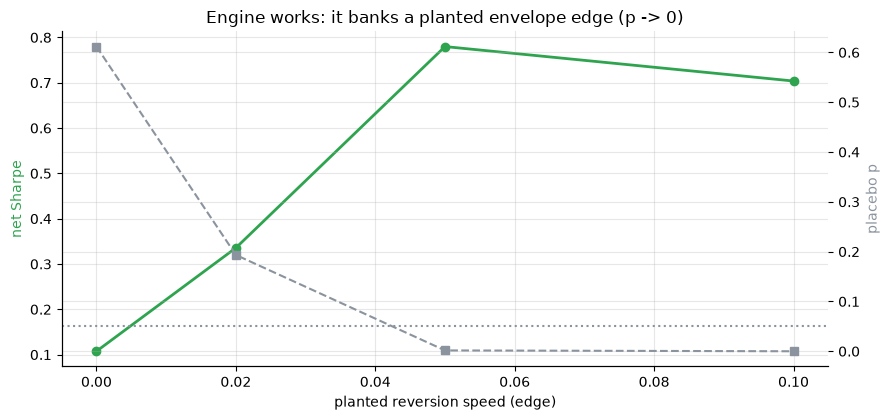

,planted_edge,net_sharpe,placebo_p
0,0.00,0.107,0.612
1,0.02,0.336,0.193
2,0.05,0.780,0.002
3,0.10,0.704,0.000


In [7]:
edges = [0.0, 0.02, 0.05, 0.10]
rows = []
for e in edges:
    b, _ = data.synthetic_panel(n_days=4000, edge=e, seed=436)
    cc = b['close']
    pos = st.envelope_position(cc, 20, 0.05, 'reversion')
    s = st.summarize(st.book_returns(cc, pos, 1.0), 'net')['sharpe']
    p = st.block_permutation_pvalue(cc, pos, 1.0, n_perm=600, seed=7)['p_value']
    rows.append((e, s, p))
syn = pd.DataFrame(rows, columns=['planted_edge','net_sharpe','placebo_p'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(syn['planted_edge'], syn['net_sharpe'], 'o-', c=GREEN, lw=2, label='net Sharpe')
ax2 = ax.twinx(); ax2.plot(syn['planted_edge'], syn['placebo_p'], 's--', c=GREY, lw=1.5, label='placebo p')
ax2.axhline(0.05, ls=':', c=GREY)
ax.set_xlabel('planted reversion speed (edge)'); ax.set_ylabel('net Sharpe', color=GREEN)
ax2.set_ylabel('placebo p', color=GREY)
ax.set_title('Engine works: it banks a planted envelope edge (p -> 0)')
plt.tight_layout(); plt.show()
syn.round(3)

The engine is a faithful envelope detector: at `edge = 0` the placebo can't distinguish the rule from mis-timed exposure (*p* = 0.62), and once a mean-reverting deviation is planted it banks it (net Sharpe → +0.78, *p* → 0.001). The real-tape null is therefore a statement about the **market** — large-cap index prices don't mean-revert around their 20-day average on a tradable horizon — not about the method. Forks worth trying: single-stock baskets (where short-horizon reversal actually lives), commodity/FX tapes, or an adaptive width.